# Análise do Experimento 1 — 5 Réplicas por FPS (nível IEEE)

**Objetivo:** consolidar **5 execuções independentes** (`r1`…`r5`) para cada um dos
9 FPS (1, 2, 3, 4, 5, 10, 15, 20, 30) e caracterizar o **trade-off entre frequência
de captura, custo computacional (CPU/RAM/Temperatura), latência e consumo energético**
em um pipeline de visão embarcado no Raspberry Pi 5.

**Decisões metodológicas travadas** (ver `CONTEXTO_NOTEBOOK_ANALISE.md`):
- **Dois níveis de agregação:** *Nível observação* (184 animais × 5 runs) para boxplots/distribuições;
  *Nível run* (5 escalares/FPS) para média ± IC e testes de hipótese. **Não achatar os 184 animais
  como réplicas do tratamento FPS.**
- **Latência** = `weight_prediction_final − last_image_capture_time` (campo do animal, direto).
- **Energia** = integral de $P(t)$ na janela `[load_model_start, max(weight_prediction_final)]`
  (inclui o carregamento do modelo até a última predição).
- **Testes:** Kruskal-Wallis global → **Mann-Whitney + Holm** nos 8 pares consecutivos
  (1→2, 2→3, 3→4, 4→5, 5→10, 10→15, 15→20, 20→30) → **correlação bisserial por postos** como tamanho de efeito.
  Jonckheere-Terpstra (opcional) como reforço de tendência monotônica.
- **Error bars:** cada figura agregada é produzida em **duas versões — IC 95% e ±1 DP**.
- **Não usa** `report.md` (pesos/MAE/MAPE/R² são dados simulados — escopo do Experimento 2).

## 1. Imports e configuração

In [29]:
import json
import re
import warnings
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")

# ── Caminho dos dados ──────────────────────────────────────────────────────
BASE_DIR = Path("../power_runs/battery_mas-single_20260708_104924")  # 45 runs, todos OK
FPS_LIST = [1, 2, 3, 4, 5, 10, 15, 20, 30]
RUNS = [1, 2, 3, 4, 5]
N_RUNS = len(RUNS)
CONSEC = list(zip(FPS_LIST[:-1], FPS_LIST[1:]))   # 8 pares consecutivos

# ── Estilo gráfico ──────────────────────────────────────────────────────────
PALETTE = plt.cm.viridis(np.linspace(0.15, 0.9, len(FPS_LIST)))
FPS_COLOR = {fps: PALETTE[i] for i, fps in enumerate(FPS_LIST)}
ACCENT_MEAN = "#1b4f72"
ACCENT_P95 = "#e67e22"

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.35,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "font.size": 11,
    "pdf.fonttype": 42,
})

# t-crítico para IC 95% com n=5 (df=4)
T95 = stats.t.ppf(0.975, N_RUNS - 1)

print(f"BASE_DIR: {BASE_DIR.resolve()}")
print(f"FPS: {FPS_LIST}  |  runs: {RUNS}  |  t95(df=4)={T95:.3f}")

BASE_DIR: /Users/gabriellopesbastos/Projects/PIBIC/cv-system/power_runs/battery_mas-single_20260708_104924
FPS: [1, 2, 3, 4, 5, 10, 15, 20, 30]  |  runs: [1, 2, 3, 4, 5]  |  t95(df=4)=2.776


## 2. Carregamento e consolidação dos dados

Funções que percorrem automaticamente as 45 pastas (`mas-single_{fps}fps_r{run}`),
localizam a subpasta UUID, e constroem os DataFrames:

- **`df_animals`** (Nível observação): 184 animais × 5 runs × 9 FPS.
- **`df_ts`** / **`df_power`**: séries temporais (CPU/RAM/Temp) e potência, alinhadas pela janela ativa.
- **`df_runs`** (Nível run): 1 escalar por run (9×5 = 45 linhas) — base da estatística.
- **`df_summary`**: agregado por FPS com média, DP, IC95 (9 linhas).

In [30]:
def parse_run_name(name: str):
    """mas-single_10fps_r1 -> (10, 1)."""
    m = re.search(r"_(\d+)fps_r(\d+)", name)
    return int(m.group(1)), int(m.group(2))

def uuid_dir(run_dir: Path) -> Path:
    """Única subpasta dentro do run (nome = timestamp/pid)."""
    subs = [p for p in run_dir.iterdir() if p.is_dir()]
    assert len(subs) == 1, f"Esperava 1 subpasta em {run_dir}, achei {len(subs)}"
    return subs[0]


def load_animals(run_dir: Path, fps: int, run: int):
    """Lê metrics.json -> DataFrame por animal + metadados de janela/contagens."""
    m = json.load(open(uuid_dir(run_dir) / "metrics.json"))
    load_start = pd.to_datetime(m.get("load_model_start"))

    rows, first_cap, last_pred = [], None, None
    total_suited = total_frames = 0
    for aid, a in m["animals"].items():
        fc = pd.to_datetime(a.get("first_image_capture_time"))
        lc = pd.to_datetime(a.get("last_image_capture_time"))
        wpf = pd.to_datetime(a.get("weight_prediction_final"))
        latency = (wpf - lc).total_seconds() if pd.notna(wpf) and pd.notna(lc) else np.nan
        passage = (lc - fc).total_seconds() if pd.notna(lc) and pd.notna(fc) else np.nan

        pred_time = 0.0
        for im in a.get("imgs", {}).values():
            s = pd.to_datetime(im.get("weight_prediction_start"))
            e = pd.to_datetime(im.get("weight_prediction_final"))
            if pd.notna(s) and pd.notna(e):
                pred_time += (e - s).total_seconds()

        rows.append(dict(fps=fps, run=run, animal_id=aid,
                         total_images=a.get("total_of_images", 0),
                         suited_images=a.get("suitable_images", 0),
                         passage_time_s=passage, pred_time_s=pred_time,
                         latency_s=latency))
        total_suited += a.get("suitable_images", 0)
        total_frames += a.get("total_of_images", 0)
        if pd.notna(wpf) and (last_pred is None or wpf > last_pred): last_pred = wpf
        if pd.notna(fc) and (first_cap is None or fc < first_cap): first_cap = fc

    df = pd.DataFrame(rows)
    df["conversion_rate"] = df["suited_images"] / df["total_images"].replace(0, np.nan)
    meta = dict(load_model_start=load_start, first_capture=first_cap,
                last_prediction=last_pred, total_suited=total_suited,
                total_frames=total_frames)
    return df, meta


def load_resources(run_dir: Path, meta: dict):
    """Lê cpu/mem/temp/power.csv, alinha (merge_asof) e recorta na janela ativa."""
    ud = uuid_dir(run_dir)
    t0, t1 = meta["load_model_start"], meta["last_prediction"]

    cpu  = pd.read_csv(ud / "cpu.csv",  parse_dates=["timestamp"])
    mem  = pd.read_csv(ud / "mem.csv",  parse_dates=["timestamp"])
    temp = pd.read_csv(ud / "temp.csv", parse_dates=["timestamp"])
    power = pd.read_csv(run_dir / "power.csv", skipinitialspace=True,
                        parse_dates=["Datetime"])

    cores = [c for c in cpu.columns if c.startswith("cpu_core_")]
    cpu["cpu_mean"] = cpu[cores].mean(axis=1)
    cpu["cpu_max"]  = cpu[cores].max(axis=1)
    mem["ram_pct"] = mem["percent"]
    mem["ram_used_gb"] = mem["used"] / 1e9

    base = cpu[["timestamp", "cpu_mean", "cpu_max"]].sort_values("timestamp")
    base = pd.merge_asof(base, mem[["timestamp", "ram_pct", "ram_used_gb"]]
                         .sort_values("timestamp"), on="timestamp",
                         tolerance=pd.Timedelta("2s"), direction="nearest")
    base = pd.merge_asof(base, temp[["timestamp", "temperature"]]
                         .sort_values("timestamp"), on="timestamp",
                         tolerance=pd.Timedelta("2s"), direction="nearest")
    base = base[(base["timestamp"] >= t0) & (base["timestamp"] <= t1)].copy()
    base["t_rel_s"] = (base["timestamp"] - t0).dt.total_seconds()

    power = power.rename(columns={"Datetime": "timestamp", "Power[W]": "power_w",
                                  "Time[S]": "t_s"})
    power["power_w"] = pd.to_numeric(power["power_w"], errors="coerce")
    pw = power[["timestamp", "power_w"]].sort_values("timestamp")
    pw = pw[(pw["timestamp"] >= t0) & (pw["timestamp"] <= t1)].copy()
    pw["t_rel_s"] = (pw["timestamp"] - t0).dt.total_seconds()
    return base, pw

In [31]:
# ── Loop de carregamento sobre os 45 runs ──────────────────────────────────
animal_frames, ts_frames, pw_frames, run_rows = [], [], [], []
missing = []

for run_dir in sorted(BASE_DIR.iterdir()):
    if not run_dir.is_dir() or not run_dir.name.startswith("mas-single_"):
        continue
    fps, run = parse_run_name(run_dir.name)
    try:
        an_df, meta = load_animals(run_dir, fps, run)
        res_df, pw_df = load_resources(run_dir, meta)
    except Exception as e:
        print(f"  [ERRO] {run_dir.name}: {e}")
        missing.append((fps, run)); continue

    animal_frames.append(an_df)
    an_df = an_df  # alias p/ agregação abaixo
    duration = (meta["last_prediction"] - meta["load_model_start"]).total_seconds()
    energy = float(np.trapezoid(pw_df["power_w"].fillna(0.0).values,
                                pw_df["t_rel_s"].values))

    run_rows.append(dict(
        fps=fps, run=run, duration_s=duration,
        cpu_mean=res_df["cpu_mean"].mean(),
        cpu_p95=np.percentile(res_df["cpu_mean"].dropna(), 95),
        cpu_max=res_df["cpu_max"].max(),
        ram_mean=res_df["ram_pct"].mean(),
        ram_p95=np.percentile(res_df["ram_pct"].dropna(), 95),
        temp_mean=res_df["temperature"].mean(),
        temp_max=res_df["temperature"].max(),
        energy_j=energy,
        power_mean_w=energy / duration if duration else np.nan,
        latency_mean=an_df["latency_s"].mean(),
        latency_p95=np.percentile(an_df["latency_s"].dropna(), 95),
        latency_max=an_df["latency_s"].max(),
        suited_mean=an_df["suited_images"].mean(),
        total_mean=an_df["total_images"].mean(),
        total_suited=meta["total_suited"], total_frames=meta["total_frames"],
    ))

    res_df["fps"] = fps; res_df["run"] = run; ts_frames.append(res_df)
    pw_df["fps"] = fps;  pw_df["run"] = run; pw_frames.append(pw_df)

df_animals = pd.concat(animal_frames, ignore_index=True)
df_ts      = pd.concat(ts_frames, ignore_index=True)
df_power   = pd.concat(pw_frames, ignore_index=True)
df_runs    = pd.DataFrame(run_rows)

assert len(df_runs) == 45, f"Esperava 45 runs, obtive {len(df_runs)} (missing={missing})"
print(f"✔ 45 runs carregados | df_animals={len(df_animals):,} | "
      f"df_ts={len(df_ts):,} | df_power={len(df_power):,} | missing={missing}")
df_runs.head()

✔ 45 runs carregados | df_animals=8,280 | df_ts=64,529 | df_power=64,236 | missing=[]


,fps,run,duration_s,cpu_mean,cpu_p95,cpu_max,ram_mean,ram_p95,temp_mean,temp_max,energy_j,power_mean_w,latency_mean,latency_p95,latency_max,suited_mean,total_mean,total_suited,total_frames
0,10,1,1417.510302,18.436917,61.0125,100.0,3.863559,4.0,64.373093,78.20,6308.458753,4.450379,0.165063,0.483523,2.522154,9.554348,77.027174,1758,14173
1,10,2,1417.510388,18.547334,61.4500,100.0,3.915466,4.0,65.438912,78.20,6398.669793,4.514020,0.165928,0.488080,2.565903,9.554348,77.027174,1758,14173
2,10,3,1417.511662,18.562782,61.4250,100.0,3.907415,4.0,63.958263,77.65,6329.669255,4.465338,0.165595,0.502853,2.562160,9.554348,77.027174,1758,14173
3,10,4,1417.512286,18.480208,60.7500,100.0,3.935099,4.0,63.413701,76.55,6320.490737,4.458861,0.164344,0.511276,2.569760,9.554348,77.027174,1758,14173
4,10,5,1417.510715,18.564319,61.2500,100.0,3.918291,4.0,63.675494,77.65,6349.814059,4.479553,0.167489,0.511648,2.619078,9.554348,77.027174,1758,14173


In [32]:
# ── df_summary: agregado por FPS (média, DP, IC95) — Nível run ──────────────
def summarize(metric):
    g = df_runs.groupby("fps")[metric]
    mean = g.mean(); sd = g.std(ddof=1); n = g.count()
    se = sd / np.sqrt(n)
    return mean, sd, se * T95   # média, desvio-padrão, half-width do IC95

METRICS_SUMMARY = ["cpu_mean", "cpu_p95", "cpu_max", "ram_mean", "ram_p95",
                   "temp_mean", "temp_max", "energy_j", "power_mean_w",
                   "latency_mean", "latency_p95", "latency_max",
                   "suited_mean", "total_mean"]

rows = []
for met in METRICS_SUMMARY:
    mean, sd, hw = summarize(met)
    for fps in FPS_LIST:
        rows.append(dict(fps=fps, metric=met,
                         mean=mean.loc[fps], sd=sd.loc[fps], ci95=hw.loc[fps]))
df_summary = pd.DataFrame(rows)

print(f"df_summary: {len(df_summary)} linhas (9 FPS × {len(METRICS_SUMMARY)} métricas)")
df_summary.head()

df_summary: 126 linhas (9 FPS × 14 métricas)


,fps,metric,mean,sd,ci95
0,1,cpu_mean,1.906176,0.004934,0.006126
1,2,cpu_mean,3.679336,0.016032,0.019906
2,3,cpu_mean,5.370035,0.019214,0.023858
3,4,cpu_mean,7.111397,0.017711,0.021991
4,5,cpu_mean,8.758220,0.029699,0.036876


## 3. Helpers estatísticos e de plotagem

Correção de Holm, correlação bisserial por postos, Jonckheere-Terpstra (opcional) e
um plotter de métrica agregada com **duas variantes de barra de erro (IC95 / ±1 DP)**.

In [33]:

def fdr_bh(pvals):
    """Correção Benjamini-Hochberg (FDR) - menos conservadora que Holm."""
    p = np.asarray(pvals, float); m = len(p)
    order = np.argsort(p)
    adj = np.empty(m)
    for i, idx in enumerate(order):
        adj[idx] = p[idx] * m / (i + 1)
    adj[order] = np.minimum.accumulate(adj[order][::-1])[::-1]
    return np.minimum(adj, 1.0)

def holm(pvals):
    """Correção de Holm (step-down). Retorna p-values ajustados na ordem original."""
    p = np.asarray(pvals, float); m = len(p)
    order = np.argsort(p)
    adj = np.empty(m)
    for i, idx in enumerate(order):
        adj[idx] = (m - i) * p[idx]
    adj[order] = np.maximum.accumulate(adj[order])   # monotonicidade step-down
    return np.minimum(adj, 1.0)


def rank_biserial_mw(x, y):
    """r de bisserial por postos a partir do U de Mann-Whitney (|r| ∈ [0,1])."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    u, _ = stats.mannwhitneyu(x, y, alternative="two-sided")
    n1, n2 = len(x), len(y)
    return 1.0 - (2.0 * u) / (n1 * n2)


def jonckheere(groups, alternative="increasing"):
    """Teste de Jonckheere-Terpstra para tendência ordenada (aprox. normal)."""
    groups = [np.asarray(g, float) for g in groups]
    n = np.array([len(g) for g in groups]); N = int(n.sum())
    J = 0
    for ai in range(len(groups)):
        for bj in range(ai + 1, len(groups)):
            A, B = groups[ai], groups[bj]
            J += int(np.sum(A[:, None] < B[None, :]))
    EJ = (N ** 2 - np.sum(n ** 2)) / 4.0
    VJ = (N ** 2 * (2 * N + 3) - np.sum(n ** 2 * (2 * n + 3))) / 72.0
    z = (J - EJ) / np.sqrt(VJ)
    p = 1 - stats.norm.cdf(z) if alternative == "increasing" else stats.norm.cdf(z)
    return dict(J=J, EJ=EJ, z=z, p=p)


def stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"


def agg_metric(metric):
    """Retorna (mean_series, err_ci, err_sd) indexados por FPS."""
    mean, sd, hw = summarize(metric)
    return mean, hw, sd


def plot_metric(metric, ylabel, title, fname=None, mode="ci",
                ref_lines=None, logy=False):
    """Gráfico de linha da métrica agregada por FPS com barra de erro.
    mode: 'ci' (IC95) ou 'sd' (±1 DP)."""
    mean, hw, sd = agg_metric(metric)
    err = hw if mode == "ci" else sd
    label_err = "IC 95%" if mode == "ci" else "±1 DP"

    fig, ax = plt.subplots(figsize=(7.5, 3.0))
    ax.errorbar(mean.index, mean.values, yerr=err.values,
                fmt="-o", color=ACCENT_MEAN, ecolor=ACCENT_MEAN,
                elinewidth=1.3, capsize=3, markersize=5, label=f"Média ({label_err})")
    if ref_lines:
        for yv, lbl in ref_lines:
            ax.axhline(yv, ls=":", color="gray", lw=1.1)
            ax.text(mean.index[-1], yv, f" {lbl}", color="gray", fontsize=8, va="center")
    ax.set_xlabel("FPS"); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.set_xticks(FPS_LIST)
    if logy: ax.set_yscale("log")
    ax.legend(frameon=True, fontsize=9)
    plt.tight_layout()
    if fname:
        plt.savefig(fname, format="pdf", bbox_inches="tight", pad_inches=0.01)
    plt.show()

## 4. Frames capturados e *suited* por FPS

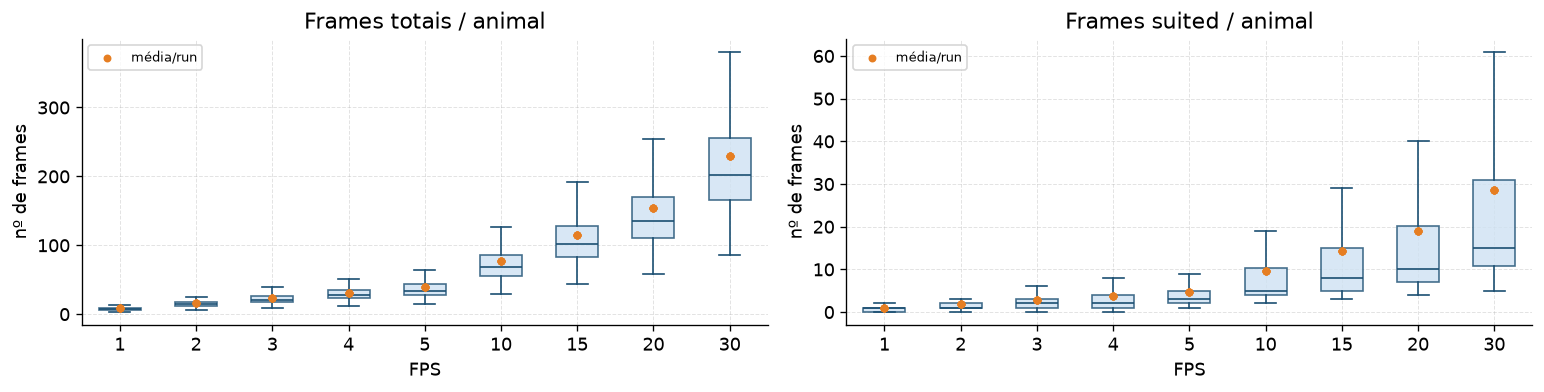

Taxa de conversão (suited/total) por FPS — média=0.117, min=0.110, max=0.119


In [34]:
# Frames totais e suited por animal (Nível observação) — distribuição conjunta
fig, axes = plt.subplots(1, 2, figsize=(13, 3.4))
for ax, col, title in [(axes[0], "total_images", "Frames totais / animal"),
                       (axes[1], "suited_images", "Frames suited / animal")]:
    data = [df_animals[df_animals.fps == f][col].dropna().values for f in FPS_LIST]
    bp = ax.boxplot(data, positions=range(1, len(FPS_LIST) + 1), widths=0.55,
                    patch_artist=True, showfliers=False,
                    boxprops=dict(facecolor="#cfe2f3", color=ACCENT_MEAN, alpha=0.8),
                    medianprops=dict(color=ACCENT_MEAN), whiskerprops=dict(color=ACCENT_MEAN),
                    capprops=dict(color=ACCENT_MEAN))
    # marcador de média (Nível run: média por run, sobreposta)
    for i, f in enumerate(FPS_LIST):
        means = df_runs[df_runs.fps == f]["suited_mean" if "suited" in col else "total_mean"].values
        ax.scatter([i + 1] * len(means), means, color=ACCENT_P95, zorder=5, s=14,
                   label="média/run" if i == 0 else "")
    ax.set_xticks(range(1, len(FPS_LIST) + 1)); ax.set_xticklabels(FPS_LIST)
    ax.set_xlabel("FPS"); ax.set_ylabel("nº de frames"); ax.set_title(title)
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Taxa de conversão (suited/total) — ~constante?
conv = df_animals.groupby("fps")["conversion_rate"].mean()
print(f"Taxa de conversão (suited/total) por FPS — média={conv.mean():.3f}, "
      f"min={conv.min():.3f}, max={conv.max():.3f}")

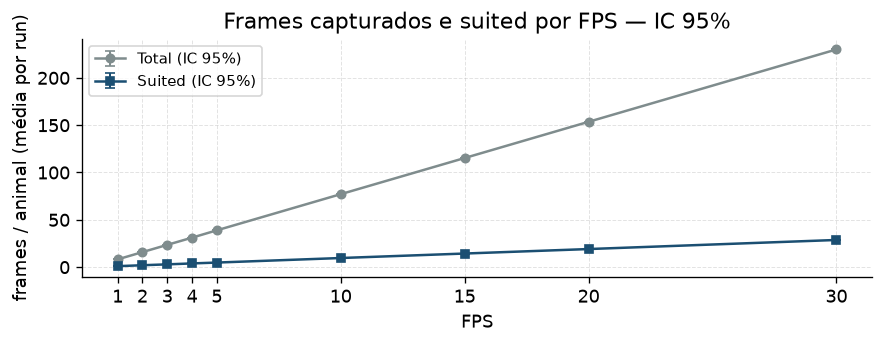

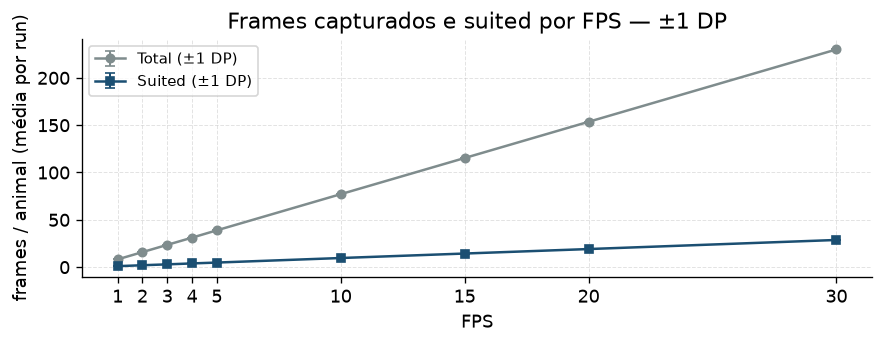

In [35]:
# Média por run (Nível B) — duas versões: IC95 e ±1 DP
for mode in ["ci", "sd"]:
    fig, ax = plt.subplots(figsize=(7.5, 3.0))
    m_tot, hw_tot, sd_tot = agg_metric("total_mean")
    m_sui, hw_sui, sd_sui = agg_metric("suited_mean")
    e_tot = hw_tot if mode == "ci" else sd_tot
    e_sui = hw_sui if mode == "ci" else sd_sui
    lbl = "IC 95%" if mode == "ci" else "±1 DP"
    ax.errorbar(m_tot.index, m_tot.values, yerr=e_tot.values, fmt="-o", color="#7f8c8d",
                label=f"Total ({lbl})", elinewidth=1.2, capsize=3, markersize=5)
    ax.errorbar(m_sui.index, m_sui.values, yerr=e_sui.values, fmt="-s", color=ACCENT_MEAN,
                label=f"Suited ({lbl})", elinewidth=1.2, capsize=3, markersize=5)
    ax.set_xlabel("FPS"); ax.set_ylabel("frames / animal (média por run)")
    ax.set_title(f"Frames capturados e suited por FPS — {lbl}")
    ax.set_xticks(FPS_LIST); ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(f"fig_frames_vs_fps_{mode}.pdf", bbox_inches="tight", pad_inches=0.01)
    plt.show()

## 5. Consumo de recursos computacionais (CPU, RAM, Temperatura)

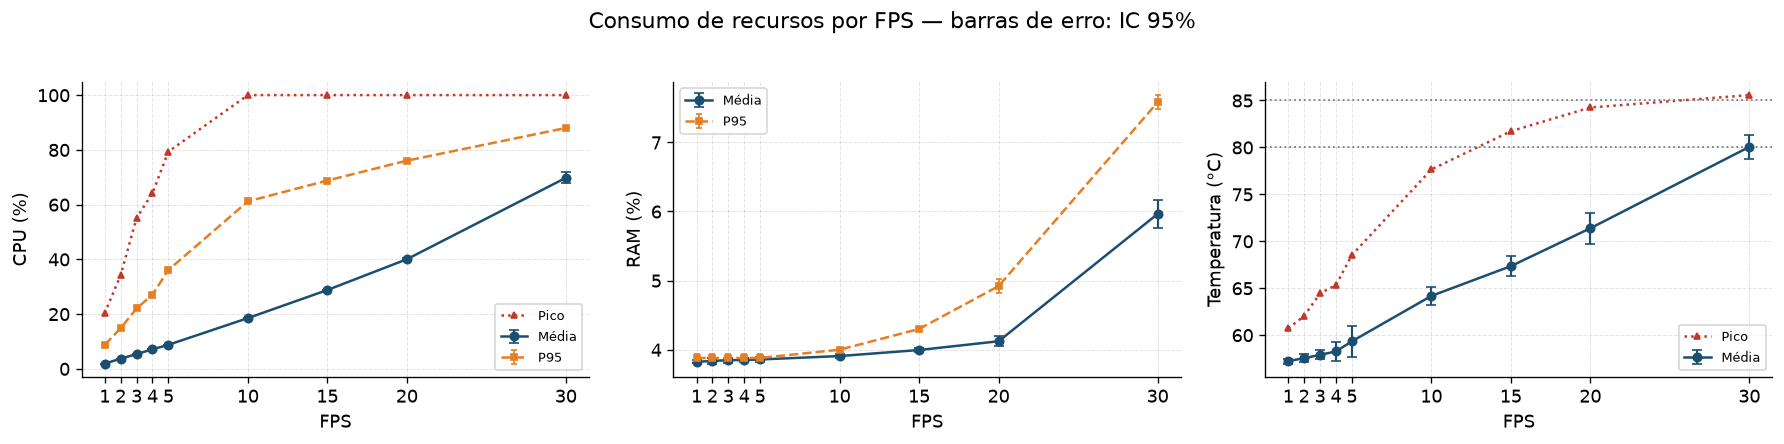

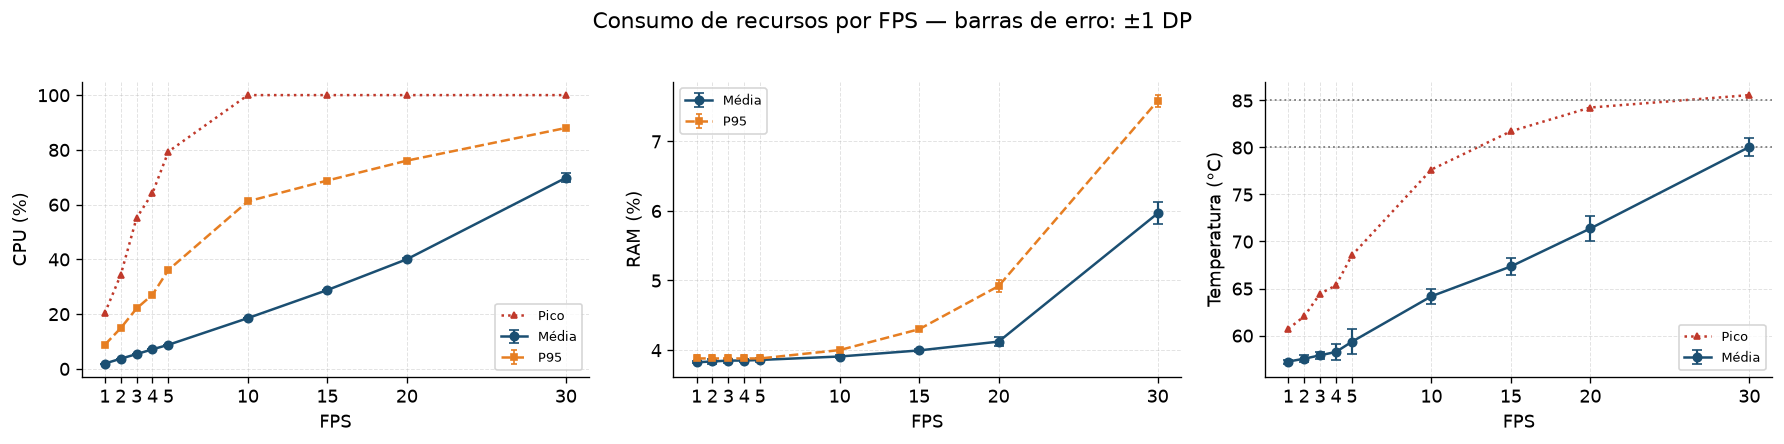

In [36]:
for mode in ["ci", "sd"]:
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
    panels = [
        ("cpu_mean", "CPU (%)", None),
        ("ram_mean", "RAM (%)", None),
        ("temp_mean", "Temperatura (°C)", [(80, "throttle 80°C"), (85, "85°C")]),
    ]
    for ax, (met, yl, refs) in zip(axes, panels):
        mean, hw, sd = agg_metric(met)
        err = hw if mode == "ci" else sd
        err_lbl = "IC 95%" if mode == "ci" else "±1 DP"
        ax.errorbar(mean.index, mean.values, yerr=err.values, fmt="-o", color=ACCENT_MEAN,
                    elinewidth=1.3, capsize=3, markersize=5, label="Média")
        
        p95_met = met.replace("_mean", "_p95")
        if p95_met in METRICS_SUMMARY:
            _, hw95, sd95 = agg_metric(p95_met)
            ax.errorbar(mean.index, df_runs.groupby("fps")[p95_met].mean(), yerr=(hw95 if mode=="ci" else sd95).values,
                        fmt="--s", color=ACCENT_P95, elinewidth=1.0, capsize=2, markersize=4, label="P95")
                        
        max_met = met.replace("_mean", "_max")
        if max_met in METRICS_SUMMARY:
            ax.plot(mean.index, df_runs.groupby("fps")[max_met].mean(), ":^", color="#c0392b",
                    markersize=4, label="Pico")
            
        ax.legend(fontsize=8)
        
        if refs:
            for yv, r_lbl in refs:
                ax.axhline(yv, ls=":", color="gray", lw=1.1)
        ax.set_xlabel("FPS"); ax.set_ylabel(yl); ax.set_xticks(FPS_LIST)
    fig.suptitle(f"Consumo de recursos por FPS — barras de erro: {err_lbl}", y=1.02)
    plt.tight_layout()
    plt.savefig(f"fig_resources_vs_fps_{mode}.pdf", bbox_inches="tight", pad_inches=0.01)
    plt.show()

## 6. Séries temporais com faixa de confiança

As 5 réplicas de cada FPS são alinhadas pelo tempo relativo (desde `load_model_start`),
reamostradas em uma grade comum de 1 s e plotadas como **média ± IC95** (faixa
sombreada). Selecionamos um subconjunto representativo de FPS (1, 5, 10, 20, 30).

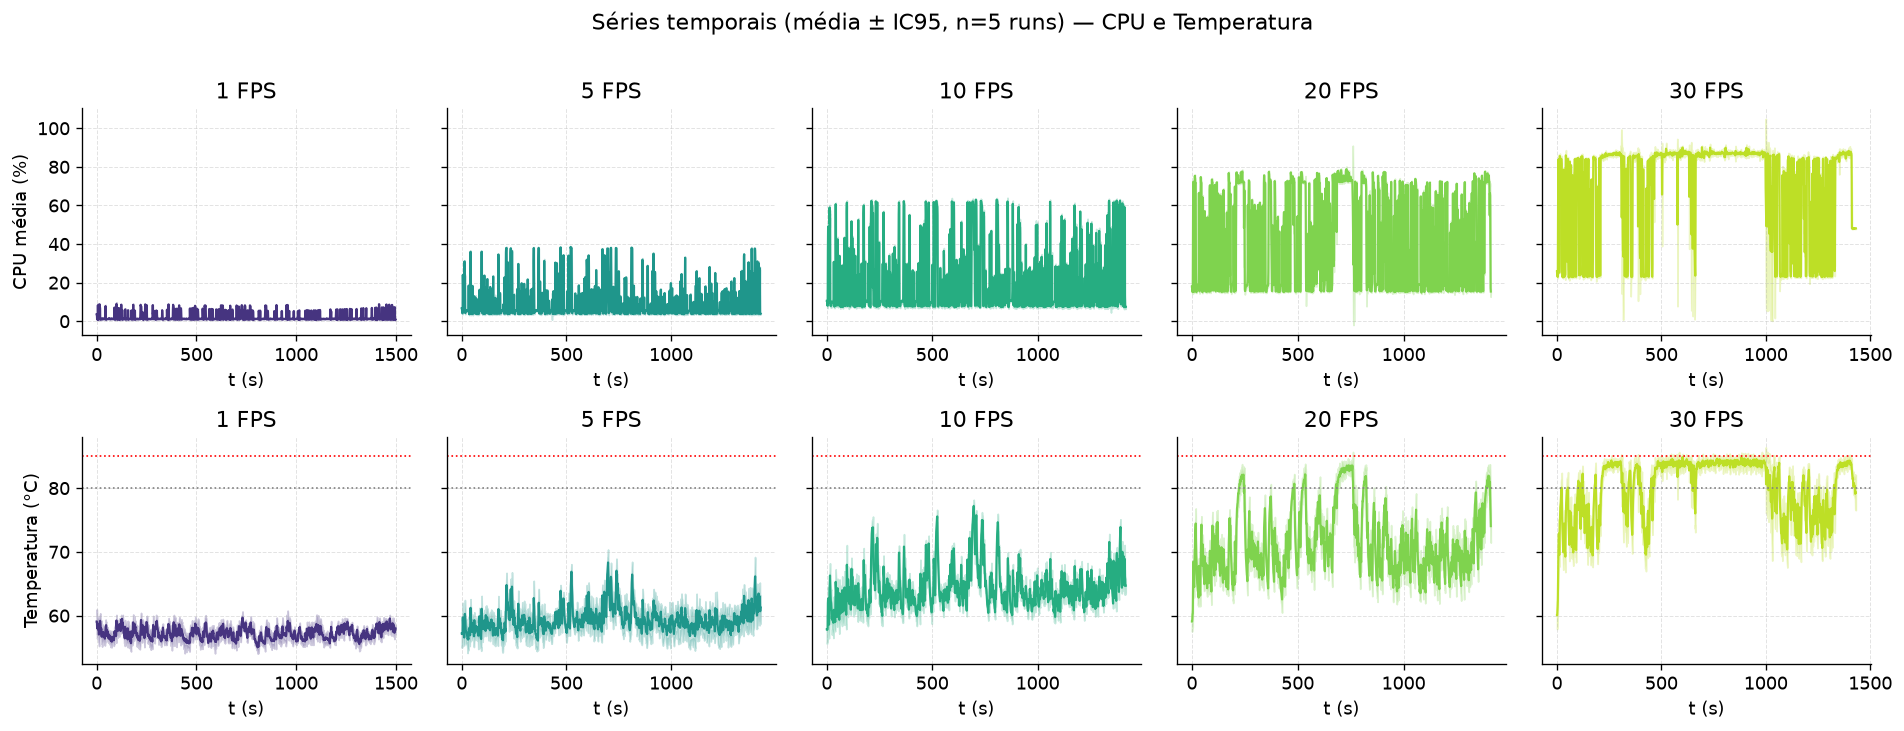

In [37]:
def ts_ci(df_ts, value_col, fps, grid_dt=1.0):
    """Alinha as 5 runs de um FPS numa grade comum -> (t_grid, mean, ci_hw)."""
    sub = df_ts[df_ts.fps == fps]
    t_max = sub["t_rel_s"].max()
    grid = np.arange(0, t_max + grid_dt, grid_dt)
    interp_runs = []
    for _, g in sub.groupby("run"):
        g = g.sort_values("t_rel_s").dropna(subset=["t_rel_s", value_col])
        if len(g) < 2: continue
        interp_runs.append(np.interp(grid, g["t_rel_s"].values, g[value_col].values))
    M = np.vstack(interp_runs)
    mean = M.mean(axis=0); sd = M.std(axis=0, ddof=1)
    hw = T95 * sd / np.sqrt(M.shape[0])
    return grid, mean, hw


SHOW_FPS = [1, 5, 10, 20, 30]
panels = [("cpu_mean", "CPU média (%)"),
          ("temperature", "Temperatura (°C)")]

fig, axes = plt.subplots(2, len(SHOW_FPS), figsize=(16, 6), sharey="row")
for r, (col, yl) in enumerate(panels):
    for c, fps in enumerate(SHOW_FPS):
        ax = axes[r][c]
        t, m, hw = ts_ci(df_ts, col, fps)
        ax.plot(t, m, color=FPS_COLOR[fps], lw=1.3)
        ax.fill_between(t, m - hw, m + hw, color=FPS_COLOR[fps], alpha=0.25)
        ax.set_title(f"{fps} FPS"); ax.set_xlabel("t (s)")
        if c == 0: ax.set_ylabel(yl)
        if col == "temperature":
            ax.axhline(80, ls=":", color="gray", lw=1); ax.axhline(85, ls=":", color="red", lw=1)
fig.suptitle("Séries temporais (média ± IC95, n=5 runs) — CPU e Temperatura", y=1.01)
plt.tight_layout(); plt.savefig("fig_timeseries_ci.pdf", bbox_inches="tight", pad_inches=0.01); plt.show()

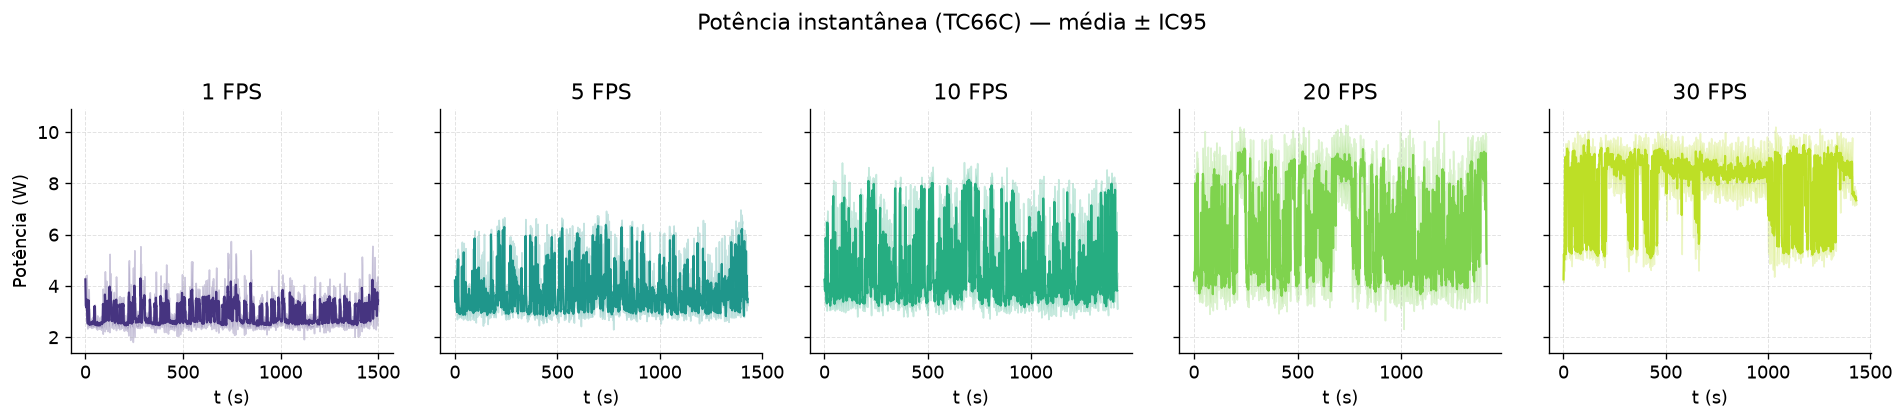

In [38]:
# Série temporal de POTÊNCIA (mesma técnica) — um painel por FPS, cor única
fig, axes = plt.subplots(1, len(SHOW_FPS), figsize=(16, 3.4), sharey=True)
for c, fps in enumerate(SHOW_FPS):
    ax = axes[c]
    t, m, hw = ts_ci(df_power, "power_w", fps)
    ax.plot(t, m, color=FPS_COLOR[fps], lw=1.3)
    ax.fill_between(t, m - hw, m + hw, color=FPS_COLOR[fps], alpha=0.25)
    ax.set_title(f"{fps} FPS"); ax.set_xlabel("t (s)")
    if c == 0: ax.set_ylabel("Potência (W)")
fig.suptitle("Potência instantânea (TC66C) — média ± IC95", y=1.02)
plt.tight_layout(); plt.savefig("fig_power_timeseries.pdf", bbox_inches="tight", pad_inches=0.01); plt.show()

## 7. Latência do pipeline

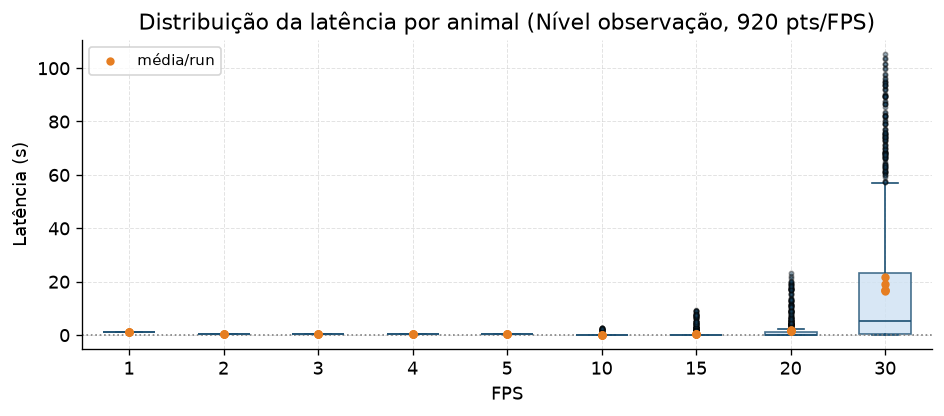

In [39]:
# (a) Boxplot da latência por FPS — distribuição conjunta (184 animais × 5 runs)
fig, ax = plt.subplots(figsize=(8, 3.6))
data = [df_animals[df_animals.fps == f]["latency_s"].dropna().values for f in FPS_LIST]
ax.boxplot(data, positions=range(1, len(FPS_LIST) + 1), widths=0.55, patch_artist=True,
           boxprops=dict(facecolor="#cfe2f3", color=ACCENT_MEAN, alpha=0.8),
           medianprops=dict(color=ACCENT_MEAN), whiskerprops=dict(color=ACCENT_MEAN),
           capprops=dict(color=ACCENT_MEAN),
           flierprops=dict(marker="o", markerfacecolor=ACCENT_MEAN, markersize=2.5, alpha=0.4))
# sobrepor média por run
for i, f in enumerate(FPS_LIST):
    means = df_runs[df_runs.fps == f]["latency_mean"].values
    ax.scatter([i + 1] * len(means), means, color=ACCENT_P95, zorder=5, s=16,
               label="média/run" if i == 0 else "")
ax.set_xticks(range(1, len(FPS_LIST) + 1)); ax.set_xticklabels(FPS_LIST)
ax.set_xlabel("FPS"); ax.set_ylabel("Latência (s)")
ax.set_title("Distribuição da latência por animal (Nível observação, 920 pts/FPS)")
ax.axhline(0, ls=":", color="gray", lw=1); ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig("fig_latency_boxplot.pdf", bbox_inches="tight", pad_inches=0.01); plt.show()

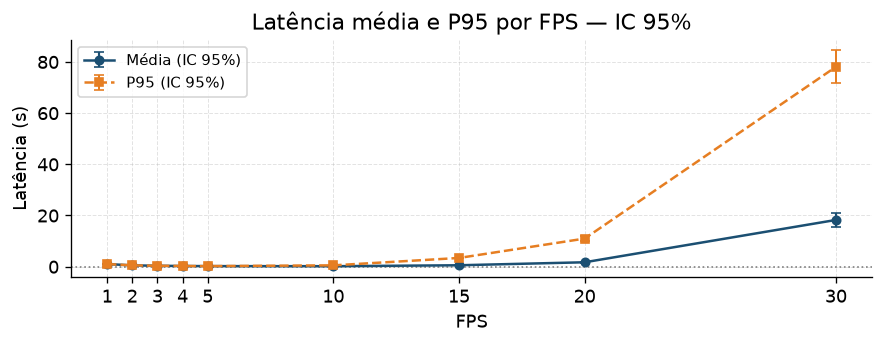

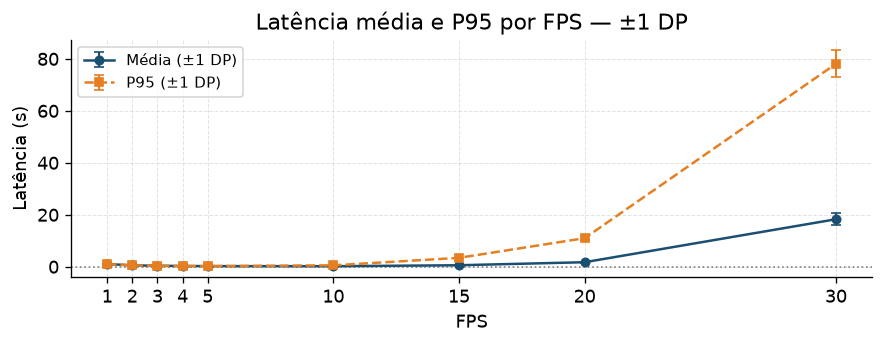

In [40]:
# (b) Latência média e P95 por FPS (Nível run) — duas versões IC95 / ±1 DP
for mode in ["ci", "sd"]:
    fig, ax = plt.subplots(figsize=(7.5, 3.0))
    m_mn, hw_mn, sd_mn = agg_metric("latency_mean")
    m_p95, hw_p95, sd_p95 = agg_metric("latency_p95")
    e_mn = hw_mn if mode == "ci" else sd_mn
    e_p95 = hw_p95 if mode == "ci" else sd_p95
    lbl = "IC 95%" if mode == "ci" else "±1 DP"
    ax.errorbar(m_mn.index, m_mn.values, yerr=e_mn.values, fmt="-o", color=ACCENT_MEAN,
                label=f"Média ({lbl})", elinewidth=1.3, capsize=3, markersize=5)
    ax.errorbar(m_p95.index, m_p95.values, yerr=e_p95.values, fmt="--s", color=ACCENT_P95,
                label=f"P95 ({lbl})", elinewidth=1.2, capsize=3, markersize=5)
    ax.axhline(0, ls=":", color="gray", lw=1)
    ax.set_xlabel("FPS"); ax.set_ylabel("Latência (s)"); ax.set_xticks(FPS_LIST)
    ax.set_title(f"Latência média e P95 por FPS — {lbl}"); ax.legend(fontsize=9)
    plt.tight_layout(); plt.savefig(f"fig_latency_vs_fps_{mode}.pdf", bbox_inches="tight", pad_inches=0.01); plt.show()

## 8. Consumo energético

Energia total por run na janela `[load_model_start, última predição]`
( $E=\int P\,dt$ ) e **custo energético marginal por frame suited**
( $E / \sum \text{suited}$ ).

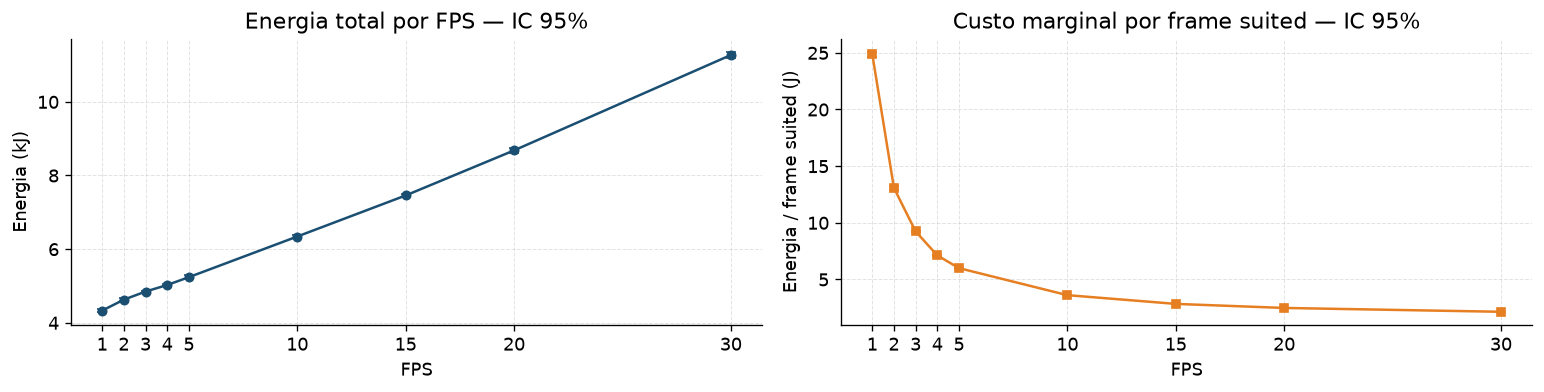

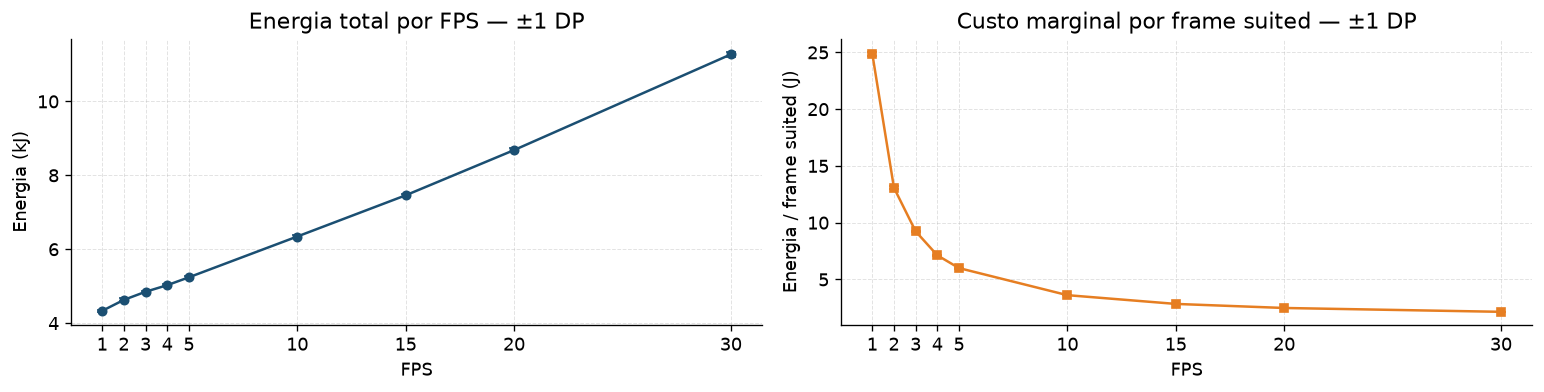

In [41]:
df_runs["energy_per_suited_J"] = df_runs["energy_j"] / df_runs["total_suited"].replace(0, np.nan)
# registrar métrica nova no df_summary para agg_metric funcionar
for met in ["energy_per_suited_J"]:
    mean, sd, hw = summarize(met)
    if met not in [r["metric"] for r in rows]:
        for fps in FPS_LIST:
            df_summary.loc[len(df_summary)] = dict(fps=fps, metric=met,
                                                   mean=mean.loc[fps], sd=sd.loc[fps], ci95=hw.loc[fps])

for mode in ["ci", "sd"]:
    fig, axes = plt.subplots(1, 2, figsize=(13, 3.4))
    # Energia total
    mE, hwE, sdE = agg_metric("energy_j")
    err = hwE if mode == "ci" else sdE; lbl = "IC 95%" if mode == "ci" else "±1 DP"
    axes[0].errorbar(mE.index, mE.values/1e3, yerr=err.values/1e3, fmt="-o", color=ACCENT_MEAN,
                     elinewidth=1.3, capsize=3, markersize=5)
    axes[0].set_xlabel("FPS"); axes[0].set_ylabel("Energia (kJ)"); axes[0].set_xticks(FPS_LIST)
    axes[0].set_title(f"Energia total por FPS — {lbl}")
    # Energia por frame suited
    mEp, hwEp, sdEp = agg_metric("energy_per_suited_J")
    errp = hwEp if mode == "ci" else sdEp
    axes[1].errorbar(mEp.index, mEp.values, yerr=errp.values, fmt="-s", color=ACCENT_P95,
                     elinewidth=1.3, capsize=3, markersize=5)
    axes[1].set_xlabel("FPS"); axes[1].set_ylabel("Energia / frame suited (J)")
    axes[1].set_xticks(FPS_LIST); axes[1].set_title(f"Custo marginal por frame suited — {lbl}")
    plt.tight_layout(); plt.savefig(f"fig_energy_vs_fps_{mode}.pdf", bbox_inches="tight", pad_inches=0.01); plt.show()

## 9. Trade-off central: frames suited × custo computacional

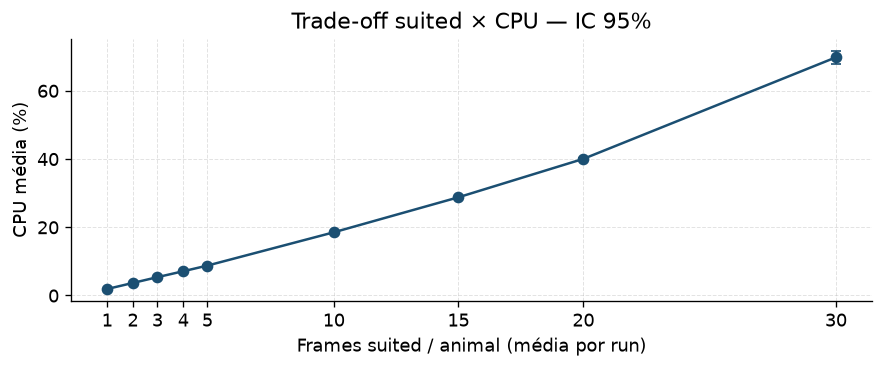

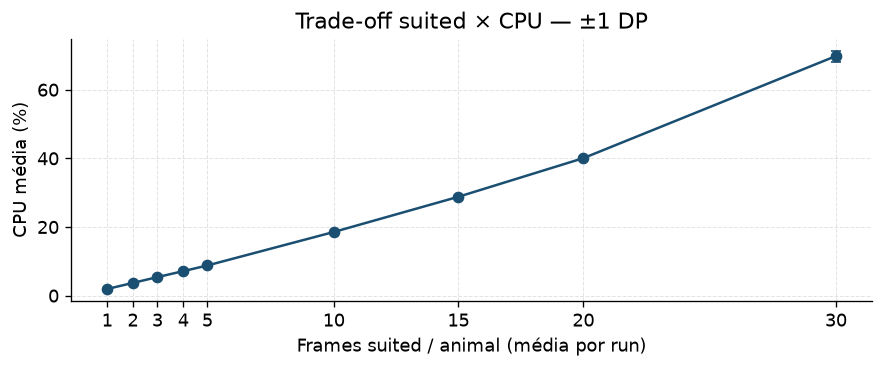

CPU ≈ 2.38 · suited + -2.25  (R²=0.989)  → ~2.38% de CPU por frame suited adicional


In [42]:
for mode in ["ci", "sd"]:
    fig, ax = plt.subplots(figsize=(7.5, 3.2))
    ms, hws, sds = agg_metric("suited_mean")
    mc, hwc, sdc = agg_metric("cpu_mean")
    es = hws if mode == "ci" else sds; ec = hwc if mode == "ci" else sdc
    lbl = "IC 95%" if mode == "ci" else "±1 DP"
    ax.errorbar(ms.values, mc.values, xerr=es.values, yerr=ec.values, fmt="-o", color=ACCENT_MEAN,
                ecolor=ACCENT_MEAN, elinewidth=1.1, capsize=3, markersize=6)
    ax.set_xticks(ms.values); ax.set_xticklabels(FPS_LIST)
    ax.set_xlabel("Frames suited / animal (média por run)")
    ax.set_ylabel("CPU média (%)")
    ax.set_title(f"Trade-off suited × CPU — {lbl}")
    plt.tight_layout(); plt.savefig(f"fig_tradeoff_suited_cpu_{mode}.pdf", bbox_inches="tight", pad_inches=0.01); plt.show()

# Ajuste linear CPU ~ suited (Nível run)
slope, interc, r, *_ = stats.linregress(df_runs["suited_mean"], df_runs["cpu_mean"])
print(f"CPU ≈ {slope:.2f} · suited + {interc:.2f}  (R²={r**2:.3f})  "
      f"→ ~{slope:.2f}% de CPU por frame suited adicional")

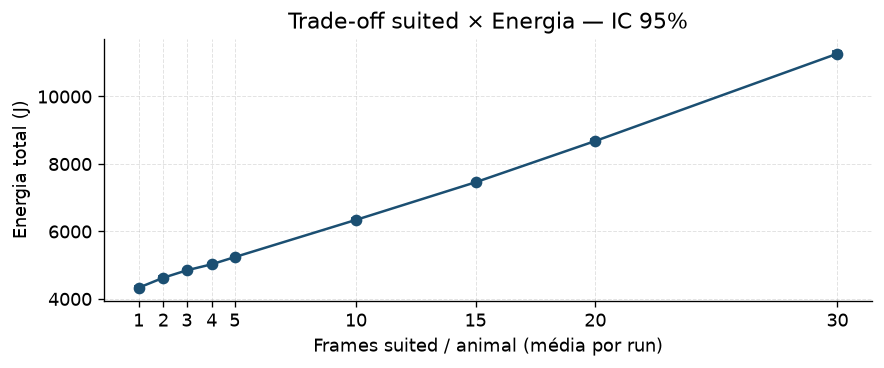

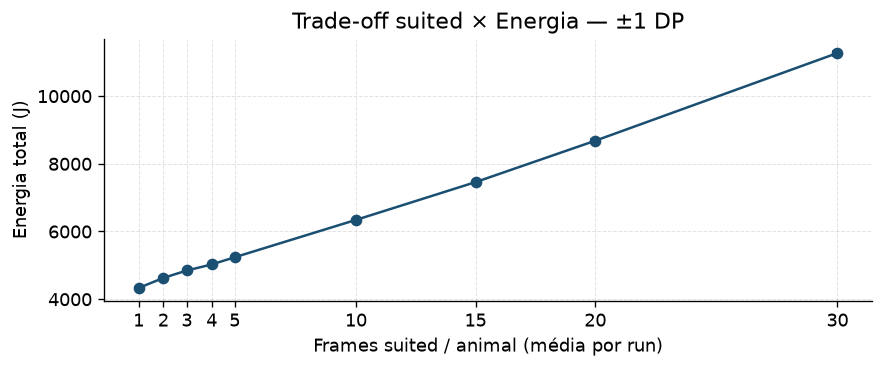

Energia ≈ 246.45 · suited + 4073.88  (R²=0.998)  → ~246.45 J por frame suited adicional


In [43]:
for mode in ["ci", "sd"]:
    fig, ax = plt.subplots(figsize=(7.5, 3.2))
    ms, hws, sds = agg_metric("suited_mean")
    me, hwe, sde = agg_metric("energy_j")
    err_s = hws if mode == "ci" else sds; err_e = hwe if mode == "ci" else sde
    lbl = "IC 95%" if mode == "ci" else "±1 DP"
    ax.errorbar(ms.values, me.values, xerr=err_s.values, yerr=err_e.values, fmt="-o", color=ACCENT_MEAN,
                ecolor=ACCENT_MEAN, elinewidth=1.1, capsize=3, markersize=6)
    ax.set_xticks(ms.values); ax.set_xticklabels(FPS_LIST)
    ax.set_xlabel("Frames suited / animal (média por run)")
    ax.set_ylabel("Energia total (J)")
    ax.set_title(f"Trade-off suited × Energia — {lbl}")
    plt.tight_layout(); plt.savefig(f"fig_tradeoff_suited_energy_{mode}.pdf", bbox_inches="tight", pad_inches=0.01); plt.show()

# Ajuste linear Energia ~ suited (Nível run)
slope_e, interc_e, r_e, *_ = stats.linregress(df_runs["suited_mean"], df_runs["energy_j"])
print(f"Energia ≈ {slope_e:.2f} · suited + {interc_e:.2f}  (R²={r_e**2:.3f})  "
      f"→ ~{slope_e:.2f} J por frame suited adicional")

## 10. Testes de hipótese

Para cada métrica do **Nível run**: **Kruskal-Wallis** global (9 FPS) e
**Mann-Whitney + Holm** nos **8 pares consecutivos**, com **correlação bisserial por
postos** ($|r|$) como tamanho de efeito. $\alpha = 0{,}05$.

In [44]:
METRICS_TEST = {
    "cpu_mean": "CPU média (%)",
    "temp_mean": "Temperatura média (°C)",
    "energy_j": "Energia total (J)",
    "latency_mean": "Latência média (s)",
    "suited_mean": "Frames suited / animal",
}

test_rows = []
jt_rows = []
for met, label in METRICS_TEST.items():
    vals = {f: df_runs[df_runs.fps == f][met].dropna().values for f in FPS_LIST}
    # Global
    H, pH = stats.kruskal(*[vals[f] for f in FPS_LIST])
    # Jonckheere-Terpstra (tendência) — opcional, reforço
    jt = jonckheere([vals[f] for f in FPS_LIST], "increasing")
    jt_rows.append(dict(metric=label, J=jt["J"], z=jt["z"], p_jt=jt["p"]))
    # Consecutivos
    u_vals, pvals = [], []
    for a, b in CONSEC:
        u, p = stats.mannwhitneyu(vals[a], vals[b], alternative="two-sided")
        u_vals.append(u)
        pvals.append(p)
    padj = fdr_bh(pvals)  # Trocado de holm para FDR (Benjamini-Hochberg)
    for (a, b), u, p, pa in zip(CONSEC, u_vals, pvals, padj):
        rrb = abs(rank_biserial_mw(vals[a], vals[b]))
        test_rows.append(dict(metric=label, pair=f"{a}→{b}",
                              U=u, p_raw=p, p_fdr=pa, r_biserial=rrb,
                              sig=stars(pa)))
    test_rows.append(dict(metric=label, pair="GLOBAL(KW)", U=np.nan, p_raw=pH,
                          p_fdr=pH, r_biserial=np.nan, sig=stars(pH)))

df_tests = pd.DataFrame(test_rows)
df_jt = pd.DataFrame(jt_rows)

print("=== Kruskal-Wallis global + Mann-Whitney/FDR (Benjamini-Hochberg) nos consecutivos ===")
_disp = df_tests.copy()
_disp["p_raw"] = _disp["p_raw"].map(lambda v: f"{v:.4f}")
_disp["p_fdr"] = _disp["p_fdr"].map(lambda v: f"{v:.4f}")
_disp["r_biserial"] = _disp["r_biserial"].map(lambda v: "" if pd.isna(v) else f"{v:.2f}")
display(_disp)
print("\n=== Jonckheere-Terpstra (tendência monotônica crescente) ===")
_dispjt = df_jt.copy()
_dispjt["J"] = _dispjt["J"].map(lambda v: f"{v:.0f}")
_dispjt["z"] = _dispjt["z"].map(lambda v: f"{v:.2f}")
_dispjt["p_jt"] = _dispjt["p_jt"].map(lambda v: f"{v:.4f}")
display(_dispjt)

=== Kruskal-Wallis global + Mann-Whitney/FDR (Benjamini-Hochberg) nos consecutivos ===


,metric,pair,U,p_raw,p_fdr,r_biserial,sig
0,CPU média (%),1→2,0.0,0.0079,0.0079,1.00,**
1,CPU média (%),2→3,0.0,0.0079,0.0079,1.00,**
2,CPU média (%),3→4,0.0,0.0079,0.0079,1.00,**
3,CPU média (%),4→5,0.0,0.0079,0.0079,1.00,**
4,CPU média (%),5→10,0.0,0.0079,0.0079,1.00,**
5,CPU média (%),10→15,0.0,0.0079,0.0079,1.00,**
6,CPU média (%),15→20,0.0,0.0079,0.0079,1.00,**
7,CPU média (%),20→30,0.0,0.0079,0.0079,1.00,**
8,CPU média (%),GLOBAL(KW),NaN,0.0000,0.0000,,***
9,Temperatura média (°C),1→2,6.0,0.2222,0.2963,0.52,ns



=== Jonckheere-Terpstra (tendência monotônica crescente) ===


,metric,J,z,p_jt
0,CPU média (%),900,8.87,0.0000
1,Temperatura média (°C),868,8.24,0.0000
2,Energia total (J),900,8.87,0.0000
3,Latência média (s),500,0.99,0.1622
4,Frames suited / animal,900,8.87,0.0000


## 11. Tabela consolidada (artigo) e export LaTeX

In [45]:
tabela = pd.DataFrame({"FPS": FPS_LIST}).set_index("FPS")
for met in ["total_mean", "suited_mean", "cpu_mean", "ram_p95", "temp_mean",
            "energy_j", "latency_mean"]:
    m, sd, hw = summarize(met)
    tabela[met] = [f"{m.loc[f]:.2f} ± {sd.loc[f]:.2f}" for f in FPS_LIST]

tabela.columns = ["Total", "Suited", "CPU (%)", "RAM P95 (%)",
                  "Temp. (°C)", "Energia (J)", "Latência (s)"]
display(tabela)

# Export LaTeX manual (pandas 3.x to_latex exige jinja2; evitamos a dependência)
caption = ("Resultados consolidados por FPS (média $\\pm$ DP sobre 5 runs). "
           "CPU/RAM/Temp na janela ativa; energia pela integral de potência; "
           "latência = última predição $-$ última captura.")
label = "tab:resultados_fps_5runs"
cols = list(tabela.columns)
lines = []
lines.append("\\begin{table}[ht]")
lines.append("\\centering")
lines.append(f"\\caption{{{caption}}}")
lines.append(f"\\label{{{label}}}")
lines.append("\\resizebox{\\columnwidth}{!}{%")
lines.append("\\begin{tabular}{|c|" + "|".join("c" for _ in cols) + "|}")
lines.append("\\hline")
lines.append("\\textbf{FPS} & " + " & ".join(f"\\textbf{{{c}}}" for c in cols) + " \\\\")
lines.append("\\hline")
for fps, row in tabela.iterrows():
    lines.append(f"{fps} & " + " & ".join(str(row[c]) for c in cols) + " \\\\")
    lines.append("\\hline")
lines.append("\\end{tabular}}")
lines.append("\\end{table}")
latex = "\n".join(lines)
print(latex)

,Total,Suited,CPU (%),RAM P95 (%),Temp. (°C),Energia (J),Latência (s)
FPS,,,,,,,
1,8.14 ± 0.00,0.95 ± 0.00,1.91 ± 0.00,3.88 ± 0.04,57.23 ± 0.21,4329.73 ± 30.63,1.00 ± 0.00
2,15.81 ± 0.00,1.92 ± 0.00,3.68 ± 0.02,3.88 ± 0.04,57.53 ± 0.36,4626.47 ± 38.97,0.50 ± 0.00
3,23.46 ± 0.00,2.85 ± 0.00,5.37 ± 0.02,3.88 ± 0.04,57.89 ± 0.38,4846.10 ± 21.99,0.33 ± 0.00
4,31.07 ± 0.00,3.84 ± 0.00,7.11 ± 0.02,3.88 ± 0.04,58.26 ± 0.82,5024.51 ± 21.76,0.25 ± 0.00
5,38.82 ± 0.00,4.75 ± 0.00,8.76 ± 0.03,3.88 ± 0.04,59.33 ± 1.34,5237.33 ± 37.73,0.20 ± 0.00
10,77.03 ± 0.00,9.55 ± 0.00,18.52 ± 0.06,4.00 ± 0.00,64.17 ± 0.79,6341.42 ± 35.39,0.17 ± 0.00
15,115.23 ± 0.00,14.29 ± 0.00,28.78 ± 0.08,4.30 ± 0.00,67.34 ± 0.86,7456.51 ± 35.48,0.53 ± 0.01
20,153.48 ± 0.00,19.03 ± 0.00,40.03 ± 0.31,4.92 ± 0.08,71.38 ± 1.35,8680.15 ± 59.49,1.70 ± 0.12
30,229.95 ± 0.00,28.62 ± 0.00,69.78 ± 1.60,7.58 ± 0.08,80.05 ± 1.00,11270.42 ± 74.25,18.24 ± 2.22


\begin{table}[ht]
\centering
\caption{Resultados consolidados por FPS (média $\pm$ DP sobre 5 runs). CPU/RAM/Temp na janela ativa; energia pela integral de potência; latência = última predição $-$ última captura.}
\label{tab:resultados_fps_5runs}
\resizebox{\columnwidth}{!}{%
\begin{tabular}{|c|c|c|c|c|c|c|c|}
\hline
\textbf{FPS} & \textbf{Total} & \textbf{Suited} & \textbf{CPU (%)} & \textbf{RAM P95 (%)} & \textbf{Temp. (°C)} & \textbf{Energia (J)} & \textbf{Latência (s)} \\
\hline
1 & 8.14 ± 0.00 & 0.95 ± 0.00 & 1.91 ± 0.00 & 3.88 ± 0.04 & 57.23 ± 0.21 & 4329.73 ± 30.63 & 1.00 ± 0.00 \\
\hline
2 & 15.81 ± 0.00 & 1.92 ± 0.00 & 3.68 ± 0.02 & 3.88 ± 0.04 & 57.53 ± 0.36 & 4626.47 ± 38.97 & 0.50 ± 0.00 \\
\hline
3 & 23.46 ± 0.00 & 2.85 ± 0.00 & 5.37 ± 0.02 & 3.88 ± 0.04 & 57.89 ± 0.38 & 4846.10 ± 21.99 & 0.33 ± 0.00 \\
\hline
4 & 31.07 ± 0.00 & 3.84 ± 0.00 & 7.11 ± 0.02 & 3.88 ± 0.04 & 58.26 ± 0.82 & 5024.51 ± 21.76 & 0.25 ± 0.00 \\
\hline
5 & 38.82 ± 0.00 & 4.75 ± 0.00 & 8.76 ± 0.03 & 3.

---
## Notas

- **Energia**: janela `[load_model_start, max(weight_prediction_final)]` (inclui carregamento do modelo), $E=\int P\,dt$.
- **Latência**: campo `weight_prediction_final` do animal (não `max(imgs)`).
- **Estatística**: KW global + Mann-Whitney/Holm nos 8 consecutivos + bisserial por postos; JT opcional.
- **Error bars**: cada figura agregada tem versão IC95 e ±1 DP.
- **Não usa** `report.md` (pesos simulados — Experimento 2).